(<Figure size 1400x250 with 1 Axes>, <Axes: xlabel='Time (s)'>)

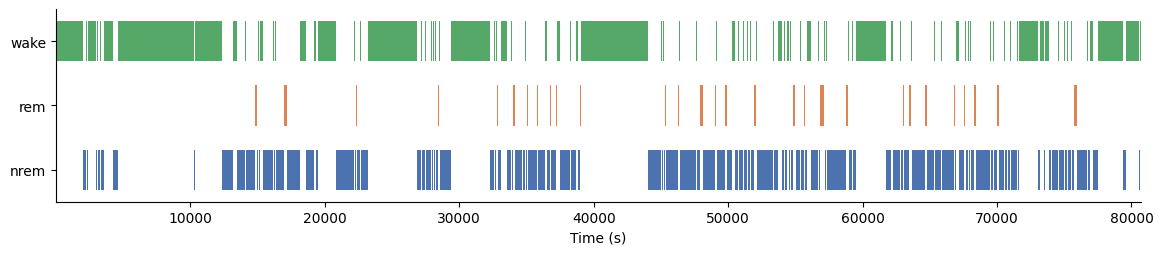

In [1]:
from nrem_sc.constants import PROCESSED_DATA_PATH, INTERIM_DATA_PATH
from nrem_sc.utils import plot_intervals

import numpy as np
import pandas as pd
import pynapple as nap
import matplotlib.pyplot as plt
import seaborn as sns

unit_id = '107b'
sleep_states    = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sleep.npz")
hd_spikes       = nap.load_file(PROCESSED_DATA_PATH / unit_id / "hd_spikes.npz")
turn_spikes     = nap.load_file(PROCESSED_DATA_PATH / unit_id / "turn_spikes.npz")

plot_intervals(sleep_states, column='state')

In [ ]:
ccg = nap.compute_crosscorrelogram(
    group=turn_spikes.restrict(sleep_states[sleep_states['state'] == 'nrem']),
    binsize=20,
    windowsize=4000,
    time_units='ms',
)

ccg

23                                                               \
            24        33        84        86        93        95        106   
-1.99  1.182471  1.068723  1.017965  1.191105  0.970932  1.032440  1.307523   
-1.98  1.375527  1.059405  1.035877  0.858970  0.966617  0.975082  1.302090   
-1.97  1.061811  1.089510  1.017965  1.179652  1.015163  1.204513  1.247760   
-1.96  1.158339  1.121765  1.001547  0.950594  0.978484  1.089798  1.222407   
-1.95  1.037679  1.118898  1.081402  1.374352  0.925622  0.803009  1.314766   
...         ...       ...       ...       ...       ...       ...       ...   
 1.95  1.110075  1.142552  1.073192  0.744441  0.895415  1.147156  1.249571   
 1.96  1.520320  1.108863  1.029906  0.847517  0.886785  0.917725  1.265870   
 1.97  1.303131  1.109580  1.004532  1.282729  0.859814  1.778091  1.264059   
 1.98  1.218669  1.144702  1.088118  1.110935  0.878154  1.261871  1.273114   
 1.99  1.073877  1.153304  1.014980  1.282729  0.884627  0.860367  1.218785   

                                     ...       205                      \
            108       112       118  ...       215       216       218   
-1.99  1.187018  1.093021  1.165279  ...  0.479781  1.149723  0.737799   
-1.98  1.269469  1.100986  1.179511  ...  0.462454  1.095279  0.684076   
-1.97  1.231087  1.064837  1.159349  ...  0.452297  1.063253  0.748544   
-1.96  1.124468  1.119366  1.120210  ...  0.463649  1.042437  0.669750   
-1.95  1.131576  1.059936  1.198488  ...  0.437957  1.016816  0.651842   
...         ...       ...       ...  ...       ...       ...       ...   
 1.95  1.232508  1.061774  1.120803  ...  0.420033  1.037633  0.841664   
 1.96  1.209763  1.031753  1.165872  ...  0.420033  1.069659  0.676913   
 1.97  1.195547  1.053197  1.191965  ...  0.424215  1.116096  0.802267   
 1.98  1.225400  1.078316  1.206790  ...  0.407486  1.076064  0.762870   
 1.99  1.241038  1.069126  1.155198  ...  0.458272  1.039234  0.698402   

                      215                           216                 218  
            220       216       218       220       218       220       220  
-1.99  0.096921  0.740569  0.772567  0.650645  1.584833  1.722136  2.320781  
-1.98  0.115094  0.697926  0.670830  0.607627  1.883054  1.650080  2.626995  
-1.97  0.087835  0.649597  0.670830  0.521591  1.721163  1.671697  2.578646  
-1.96  0.075720  0.733461  0.696264  0.583430  1.823410  1.700519  3.013792  
-1.95  0.093893  0.764733  0.705802  0.610316  1.584833  1.606847  2.739811  
...         ...       ...       ...       ...       ...       ...       ...  
 1.95  0.115094  0.682290  0.740774  0.553855  2.275002  1.880659  2.079033  
 1.96  0.090864  0.722090  0.832973  0.545789  1.823410  1.693314  2.095150  
 1.97  0.115094  0.682290  0.718519  0.553855  2.198317  1.837426  2.079033  
 1.98  0.084806  0.663811  0.858407  0.559232  2.283523  1.779781  2.465830  
 1.99  0.081777  0.659547  0.804360  0.540412  2.215358  1.700519  2.224082  

[399 rows x 136 columns]

Text(0.5, 0, 'Time (ms)')

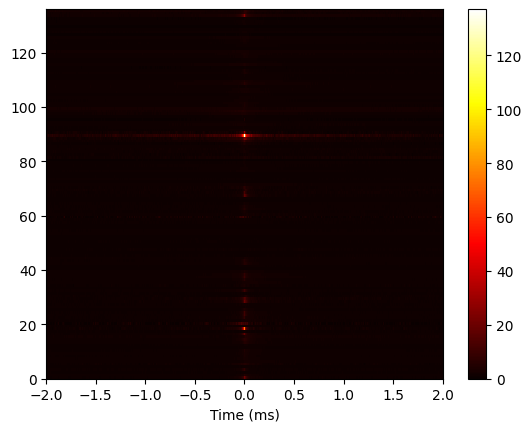

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(
    ccg.to_numpy().T,
    aspect='auto',
    origin='lower',
    cmap='hot',
    interpolation='none',
    extent=[-2, 2, 0, 136],
    )


plt.xlabel('Time (ms)')